# Analisis de Datos

En esta primera parte construiremos un flujo completo de analisis y preparacion de datos en Jupyter usando:
- `datasets/titanic/titanic3.csv`

El objetivo no es solo ejecutar codigo, sino entender que esta pasando en cada paso. Por eso, antes de cada script veras:

- Que haremos.
- Por que se hace.
- Que debes observar al ejecutar.
- Resultado esperado.

Al final exportaremos dos archivos listos para Power BI:

1. `outputs/titanic_tratado_pasajero.csv` (detalle por pasajero).
2. `outputs/titanic_tratado_agregado_dashboard.csv` (resumen por segmento).

## 1) Preparacion del entorno

### Que haremos

Importaremos las librerias principales y configuraremos una ruta flexible para encontrar el dataset.

### Por que se hace

- Si no cargamos librerias al inicio, el notebook falla en pasos posteriores.
- Una ruta flexible evita errores cuando cambias de carpeta (ejemplo: ejecutar desde raiz o desde `notebooks/`).
- Ajustar opciones de visualizacion (`display`) mejora la lectura de tablas durante el analisis.

### Que debes observar al ejecutar

- Debe imprimirse una ruta valida del archivo `titanic3.csv`.
- Si no se encuentra el archivo, aparecera un `FileNotFoundError` (eso te indica que debes revisar la ubicacion).

### Resultado esperado

Notebook listo para trabajar y ruta de datos validada.

In [6]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Rutas posibles (si ejecutas desde la raiz del proyecto o desde /notebooks)
possible_paths = [
    Path("datasets/titanic/titanic3.csv"),
    Path("../datasets/titanic/titanic3.csv")
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break
    else:
        raise FileNotFoundError("No se encontro titanic3.csv en rutas esperadas.")

print("Archivo encontrado en:", DATA_PATH.resolve())

Archivo encontrado en: C:\Users\garyDav\anaconda_projects\datasets\titanic\titanic3.csv


## 2) Carga de datos

### Que haremos

Leeremos el CSV con `pd.read_csv()` y haremos una inspeccion inicial.

### Por que se hace

Este paso confirma que los datos realmente entraron al DataFrame y evita avanzar con una tabla vacia o mal parseada.

### Que debes observar al ejecutar

- `Dimension inicial` debe mostrar filas y columnas (por ejemplo, algo como `(1309, 14)` antes de limpieza).
- `head(5)` debe mostrar columnas como `pclass`, `survived`, `name`, `sex`, `age`, `fare`, etc.

### Resultado esperado

DataFrame original cargado en la variable `df`.

In [11]:
df = pd.read_csv(DATA_PATH)
print("Dimension inicial:", df.shape)
df.head(5)

Dimension inicial: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 3) Propiedades del dataset Titanic3 (solo contexto)

### Que haremos

Antes de seguir con scripts de exploracion y limpieza, documentaremos las propiedades principales del dataset para entender su estructura conceptual.

### Por que se hace

- Ayuda a interpretar correctamente cada variable antes de transformarla.
- Permite decidir mejores estrategias de limpieza segun el tipo de dato.
- Facilita conectar el analisis tecnico con preguntas de negocio para el dashboard.

### Tabla de propiedades del dataset

| Propiedad | Tipo | Descripcion | Ejemplo | Uso en analisis |
|---|---|---|---|---|
| `pclass` | Numerica discreta | Clase del pasajero (1, 2, 3) | `1` | Segmentacion socioeconomica y comparacion de supervivencia |
| `survived` | Binaria (objetivo) | Estado de supervivencia | `1` (sobrevivio), `0` (no sobrevivio) | Variable objetivo principal del analisis |
| `name` | Texto | Nombre completo del pasajero | `Allen, Miss. Elisabeth Walton` | Extraccion de titulos (`Mr`, `Mrs`, etc.) |
| `sex` | Categorica | Sexo del pasajero | `female`, `male` | Segmentacion demografica clave |
| `age` | Numerica continua | Edad del pasajero | `29` | Analisis por rango etario y supervivencia |
| `sibsp` | Numerica discreta | Numero de hermanos/esposo(a) a bordo | `1` | Construccion de tamano de familia |
| `parch` | Numerica discreta | Numero de padres/hijos a bordo | `2` | Construccion de tamano de familia |
| `ticket` | Texto | Identificador del boleto | `PC 17599` | Identificacion y analisis auxiliar |
| `fare` | Numerica continua | Tarifa pagada por el boleto | `71.2833` | Analisis economico y relacion con clase |
| `cabin` | Categorica/texto | Cabina asignada | `C85` | Variable con muchos nulos; util en analisis especificos |
| `embarked` | Categorica | Puerto de embarque | `S`, `C`, `Q` | Segmentacion geografica y comparativos |
| `boat` | Categorica/texto | Bote de rescate asignado | `2`, `11`, `D` | Informacion de contexto posterior al evento |
| `body` | Numerica/texto | Identificador de cuerpo recuperado | `135` | Columna con muchos nulos; normalmente se elimina |
| `home.dest` | Texto | Lugar de origen/destino reportado | `New York, NY` | Enriquecimiento geografico (requiere limpieza textual) |

### Resultado esperado

Entender que el dataset es mixto (numerico + categorico + texto), identificar la variable objetivo (`survived`) y ubicar las columnas mas utiles para limpieza, segmentacion y dashboard.


## 4) Analisis preliminar de estructura

### Que haremos

Exploraremos la estructura del dataset con `head`, `tail`, `shape`, nombres de columnas, tipos de dato y estadisticas descriptivas.

### Por que se hace

- Te da contexto sobre volumen y calidad de datos.
- Ayuda a detectar columnas numericas que llegaron como texto.
- Permite identificar rapidamente variables candidatas para limpieza y modelado.

### Que debes observar al ejecutar

- Que tipos como `age` y `fare` sean numericos.
- Si aparecen valores extremos en estadisticas (`max`, `mean`, `std`).
- Si columnas categoricas tienen muchos valores unicos (`name`, `ticket`).

### Resultado esperado

Mapa claro del dataset antes de limpiar.

In [17]:
display(df.head(10))
display(df.tail(8))

print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nResumen estadistico (numerico):")
display(df.describe())

print("\nResumen estadistico (incluye categoricas):")
display(df.describe(include="all"))

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1301,3,0,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN
1302,3,0,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3,0,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,NaN,NaN,NaN
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,NaN,NaN,NaN


Shape: (1309, 14)

Columnas:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

Tipos de datos:
pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

Resumen estadistico (numerico):


,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000



Resumen estadistico (incluye categoricas):


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


## 5) Diagnostico de valores faltantes

### Que haremos

Calcularemos nulos por columna en cantidad y porcentaje.

### Por que se hace

Antes de imputar o eliminar columnas, necesitas evidencia: no es lo mismo una columna con 1% de nulos que con 80%.

### Que debes observar al ejecutar

- Columnas con porcentaje alto de nulos (`body`, `cabin`, `boat`, etc.).
- Columnas criticas para analisis (`age`, `embarked`) con nulos que si conviene tratar.

### Resultado esperado

Reporte `missing_report` para tomar decisiones de limpieza.

In [20]:
null_count = df.isnull().sum().sort_values(ascending=False)
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "nulos": null_count,
    "porcentaje": null_pct.round(2)
})

display(missing_report)

,nulos,porcentaje
body,1188,90.76
cabin,1014,77.46
boat,823,62.87
home.dest,564,43.09
age,263,20.09
embarked,2,0.15
fare,1,0.08
pclass,0,0.00
survived,0,0.00
name,0,0.00


## 6) Limpieza de datos

En esta fase generaremos una version tratada del dataset para que sea consistente en analisis y visualizacion.

### 5.1 Copia de trabajo

### Que haremos

Crear `clean_df` como copia del original.

### Por que se hace

Buena practica: mantienes `df` intacto y evitas perder trazabilidad.

### Resultado esperado

Dos versiones: `df` (original) y `clean_df` (editable).

In [24]:
clean_df = df.copy()

### 5.2 Imputacion de variables numericas

### Que haremos

Rellenar nulos de `age` y `fare` con la mediana.

### Por que se hace

La mediana es robusta frente a outliers, especialmente util en `fare`, donde hay tarifas muy altas.

### Que debes observar al ejecutar

- El conteo final de nulos en esas columnas debe ser 0.

### Resultado esperado

`age` y `fare` sin valores faltantes.

In [27]:
num_cols = ["age", "fare"]

for col in num_cols:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

clean_df[num_cols].isnull().sum()

age     0
fare    0
dtype: int64

### 5.3 Imputacion de variables categoricas

### Que haremos

- `embarked`: completar con la moda.
- `cabin`, `boat`, `home.dest`: completar con "Unknown".

### Por que se hace

- `embarked` suele usarse en segmentacion, por eso conviene no dejar nulos.
- Etiquetar como "Unknown" conserva la fila y permite analizar "desconocidos" como categoria real.

### Que debes observar al ejecutar

Que estas columnas ya no presenten nulos al final.

### Resultado esperado

Variables categoricas listas para analisis y filtros.

In [30]:
if "embarked" in clean_df.columns:
    clean_df["embarked"] = clean_df["embarked"].fillna(clean_df["embarked"].mode()[0])

for col in ["cabin", "boat", "home.dest"]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Unknown")

### 5.4 Eliminar columna con demasiados nulos

### Que haremos

Eliminar `body` por baja utilidad y alto porcentaje de faltantes.

### Por que se hace

Columnas extremadamente incompletas agregan ruido y no ayudan al dashboard base.

### Que debes observar al ejecutar

- La dimension de columnas debe reducirse en 1 (si `body` existia).

### Resultado esperado

Estructura mas limpia y manejable.

In [33]:
if "body" in clean_df.columns:
    clean_df = clean_df.drop(columns=["body"])

print("Dimension tras limpieza:", clean_df.shape)
display(clean_df.head())

Dimension tras limpieza: (1309, 13)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON"


### 5.5 Verificacion final de nulos

### Que haremos

Revisar si aun quedan nulos despues del tratamiento.

### Por que se hace

Es control de calidad obligatorio antes de pasar a transformacion y exportacion.

### Resultado esperado

Lista vacia o con muy pocas columnas pendientes de tratar.

In [36]:
post_nulls = clean_df.isnull().sum().sort_values(ascending=False)
post_nulls[post_nulls > 0]

Series([], dtype: int64)

## 7) Data wrangling (transformacion de datos)

Crearemos variables derivadas para enriquecer el analisis en Power BI.

### 6.1 Variables de familia

### Que haremos

- `family_size = sibsp + parch + 1`
- `is_alone = 1` cuando viaja solo.

### Por que se hace

El tamano del grupo familiar es una variable muy util para entender patrones de supervivencia.

### Resultado esperado

Nuevas columnas listas para segmentacion y KPIs.

In [41]:
clean_df["family_size"] = clean_df["sibsp"] + clean_df["parch"] + 1
clean_df["is_alone"] = (clean_df["family_size"] == 1).astype(int)

clean_df[["sibsp", "parch", "family_size", "is_alone"]].head()

,sibsp,parch,family_size,is_alone
0,0,0,1,1
1,1,2,4,0
2,1,2,4,0
3,1,2,4,0
4,1,2,4,0


### 6.2 Extraccion de titulo desde `name`

### Que haremos

Extraeremos el titulo social (Mr, Mrs, Miss, etc.) con expresion regular.

### Por que se hace

El titulo captura informacion socio-demografica que puede influir en la supervivencia.

### Que debes observar al ejecutar

- La columna `title` con categorias.
- Titulos raros agrupados en `Rare` para reducir dispersion.

### Resultado esperado

Columna categorica compacta y util para visuales y slicers.

In [47]:
clean_df["title"] = clean_df["name"].str.extract(r",\s*([^\.]+)\.", expand=False) # [azAZ-0-9]
clean_df["title"] = clean_df["title"].fillna("Unknown").str.strip()

# Agrupacion de titulos poco frecuentes
rare_titles = clean_df["title"].value_counts()[clean_df["title"].value_counts() < 10].index
clean_df["title"] = clean_df["title"].replace(rare_titles, "Rare")

clean_df["title"].value_counts().head(10)

title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64

### 6.3 Tarifa por persona

### Que haremos

Crear `fare_per_person` dividiendo la tarifa total entre `family_size`.

### Por que se hace

La tarifa total no siempre representa el costo individual; esta variable da una lectura mas comparable.

### Resultado esperado

Nueva variable numerica estabilizada (sin infinitos ni nulos).

In [50]:
clean_df["fare_per_person"] = clean_df["fare"] / clean_df["family_size"]
clean_df["fare_per_person"] = clean_df["fare_per_person"].replace([np.inf, -np.inf], np.nan)
clean_df["fare_per_person"] = clean_df["fare_per_person"].fillna(clean_df["fare_per_person"].median())

clean_df[["fare", "family_size", "fare_per_person"]].head()

,fare,family_size,fare_per_person
0,211.3375,1,211.3375
1,151.5500,4,37.8875
2,151.5500,4,37.8875
3,151.5500,4,37.8875
4,151.5500,4,37.8875


### 6.4 Variables dummy

### Que haremos

Codificar variables categoricas en formato binario para escenarios de modelado.

### Por que se hace

Muchos algoritmos y flujos analiticos requieren entradas numericas.

### Que debes observar al ejecutar

- Aumento de columnas.
- Conservacion de filas.

### Resultado esperado

`model_df` listo para experimentos de ML o analisis avanzado.

In [53]:
cat_cols = ["sex", "embarked", "pclass", "title"]
cat_cols = [c for c in cat_cols if c in clean_df.columns]

model_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=False)

print("Dimension con dummies:", model_df.shape)
model_df.head(3)

Dimension con dummies: (1309, 26)


,survived,name,age,sibsp,parch,ticket,fare,cabin,boat,home.dest,family_size,is_alone,fare_per_person,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,1,"Allen, Miss. Elisabeth Walton",29.0000,0,0,24160,211.3375,B5,2,"St Louis, MO",1,1,211.3375,True,False,False,False,True,True,False,False,False,True,False,False,False
1,1,"Allison, Master. Hudson Trevor",0.9167,1,2,113781,151.5500,C22 C26,11,"Montreal, PQ / Chesterville, ON",4,0,37.8875,False,True,False,False,True,True,False,False,True,False,False,False,False
2,0,"Allison, Miss. Helen Loraine",2.0000,1,2,113781,151.5500,C22 C26,Unknown,"Montreal, PQ / Chesterville, ON",4,0,37.8875,True,False,False,False,True,True,False,False,False,True,False,False,False


## 8) Subconjuntos y filtros (seleccion de datos)

### Que haremos

Practicar slicing, seleccion de columnas y filtros booleanos sobre Titanic.

### Por que se hace

Esto replica operaciones basicas de analisis exploratorio y prepara consultas para visuales.

### Que debes observar al ejecutar

- Cantidad de filas filtradas por regla.
- Coherencia entre condiciones y resultados.

### Resultado esperado

Dominio de selecciones clave sobre el DataFrame.

In [58]:
# Subconjunto de columnas
subset_cols = ["survived", "age", "fare", "family_size", "is_alone"]
subset_cols = [c for c in subset_cols if c in clean_df.columns]
subset_df = clean_df[subset_cols]
display(subset_df.head())

# Subconjunto de filas por slicing
display(clean_df[:8])
display(clean_df[10:35])

# Filtros booleanos
older_survivors = clean_df[(clean_df["age"] > 60) & (clean_df["survived"] == 1)]
female_1st_class = clean_df[(clean_df["sex"] == "female") & (clean_df["pclass"] == 1)]

print("Mayores de 60 que sobrevivieron:", older_survivors.shape)
print("Mujeres de 1ra clase:", female_1st_class.shape)

,survived,age,fare,family_size,is_alone
0,1,29.0000,211.3375,1,1
1,1,0.9167,151.5500,4,0
2,0,2.0000,151.5500,4,0
3,0,30.0000,151.5500,4,0
4,0,25.0000,151.5500,4,0


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest,family_size,is_alone,title,fare_per_person
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,"St Louis, MO",1,1,Miss,211.33750
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,"Montreal, PQ / Chesterville, ON",4,0,Master,37.88750
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON",4,0,Miss,37.88750
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON",4,0,Mr,37.88750
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,Unknown,"Montreal, PQ / Chesterville, ON",4,0,Mrs,37.88750
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,"New York, NY",1,1,Mr,26.55000
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,"Hudson, NY",2,0,Miss,38.97915
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,Unknown,"Belfast, NI",1,1,Mr,0.00000


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest,family_size,is_alone,title,fare_per_person
10,1,0,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C,Unknown,"New York, NY",2,0,Rare,113.762500
11,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,4,"New York, NY",2,0,Mrs,113.762500
12,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.3000,B35,C,9,"Paris, France",1,1,Rare,69.300000
13,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,Unknown,S,6,Unknown,1,1,Miss,78.850000
14,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S,B,"Hessle, Yorks",1,1,Mr,30.000000
15,1,0,"Baumann, Mr. John D",male,28.0,0,0,PC 17318,25.9250,Unknown,S,Unknown,"New York, NY",1,1,Mr,25.925000
16,1,0,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,Unknown,"Montreal, PQ",2,0,Mr,123.760400
17,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C,6,"Montreal, PQ",2,0,Mrs,123.760400
18,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,76.2917,D15,C,8,Unknown,1,1,Miss,76.291700
19,1,0,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C,A,"Winnipeg, MN",1,1,Mr,75.241700


Mayores de 60 que sobrevivieron: (8, 17)
Mujeres de 1ra clase: (144, 17)


## 9) Visualizacion basica

### Que haremos

Generar 4 graficos base: histograma, boxplot, barras y scatter.

### Por que se hace

- Histograma: distribucion de edades.
- Boxplot: outliers de tarifa.
- Barras: balance de supervivencia.
- Scatter: relacion edad-tarifa.

### Que debes observar al ejecutar

- Si hay sesgos de distribucion.
- Si existen tarifas extremas.
- Si se distinguen patrones visuales entre sobrevivencia y variables economicas/edad.

### Resultado esperado

Lectura visual inicial del comportamiento del dataset.


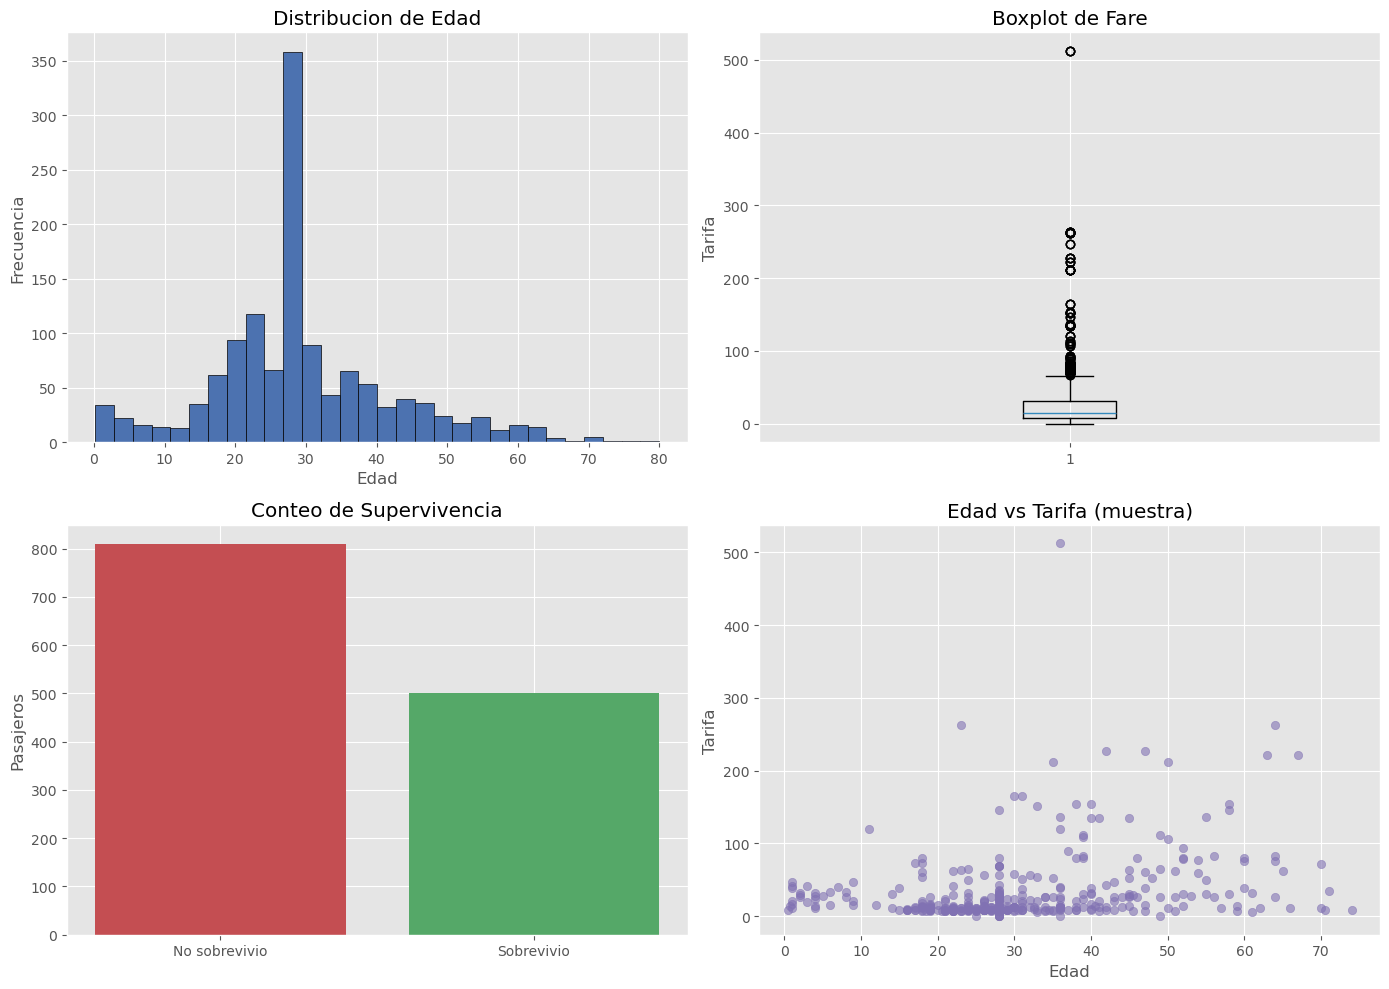

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de edad
axes[0, 0].hist(clean_df["age"], bins=30, color="#4C72B0", edgecolor="black")
axes[0, 0].set_title("Distribucion de Edad")
axes[0, 0].set_xlabel("Edad")
axes[0, 0].set_ylabel("Frecuencia")

# Boxplot de tarifa
axes[0, 1].boxplot(clean_df["fare"], vert=True)
axes[0, 1].set_title("Boxplot de Fare")
axes[0, 1].set_ylabel("Tarifa")

# Barras de supervivencia
surv_counts = clean_df["survived"].value_counts().sort_index()
axes[1, 0].bar(["No sobrevivio", "Sobrevivio"], surv_counts.values, color=["#C44E52", "#55A868"])
axes[1, 0].set_title("Conteo de Supervivencia")
axes[1, 0].set_ylabel("Pasajeros")

# Scatter edad vs tarifa (muestra)
sample_plot = clean_df.sample(n=min(400, len(clean_df)), random_state=42)
axes[1, 1].scatter(sample_plot["age"], sample_plot["fare"], alpha=0.6, color="#8172B3")
axes[1, 1].set_title("Edad vs Tarifa (muestra)")
axes[1, 1].set_xlabel("Edad")
axes[1, 1].set_ylabel("Tarifa")

plt.tight_layout()
plt.show()

## 10) Agrupacion de datos (groupby)

### Que haremos

Construir un reporte agregado por `sex` y `pclass` con volumen, supervivencia y promedios.

### Por que se hace

Los dashboards ejecutivos se apoyan en tablas agregadas para comparar segmentos rapidamente.

### Que debes observar al ejecutar

- Diferencias de tasa de supervivencia por clase y sexo.
- Brechas de tarifa/edad entre segmentos.

### Resultado esperado

`group_report` util para decisiones y visuales comparativos.

In [64]:
# Tasa de supervivencia por sexo y clase
group_report = (
    clean_df
    .groupby(["sex", "pclass"], as_index=False)
    .agg(
        total_pasajeros=("survived", "count"),
        sobrevivientes=("survived", "sum"),
        tasa_supervivencia=("survived", "mean"),
        edad_promedio=("age", "mean"),
        tarifa_promedio=("fare", "mean")
    )
)

group_report["tasa_supervivencia"] = (group_report["tasa_supervivencia"] * 100).round(2)
group_report["edad_promedio"] = group_report["edad_promedio"].round(2)
group_report["tarifa_promedio"] = group_report["tarifa_promedio"].round(2)

display(group_report)

,sex,pclass,total_pasajeros,sobrevivientes,tasa_supervivencia,edad_promedio,tarifa_promedio
0,female,1,144,139,96.53,36.35,109.41
1,female,2,106,94,88.68,27.51,23.23
2,female,3,216,106,49.07,23.91,15.32
3,male,1,179,61,34.08,38.99,69.89
4,male,2,171,25,14.62,30.60,19.90
5,male,3,493,75,15.21,26.56,12.42


### 9.1 Transformacion tipo z-score por grupo

### Que haremos

Normalizar variables dentro de cada grupo para comparaciones relativas.

### Por que se hace

El z-score ayuda a ver que tan lejos esta un valor respecto a su grupo (por sexo o clase), no respecto al total global.

### Resultado esperado

Variables estandarizadas para analisis comparativo avanzado.

In [68]:
zscore = lambda x: (x - x.mean()) / x.std(ddof=0)

z_df = clean_df.copy()
z_df["age_z_by_sex"] = z_df.groupby("sex")["age"].transform(zscore)
z_df["fare_z_by_pclass"] = z_df.groupby("pclass")["fare"].transform(zscore)

z_df[["sex", "pclass", "age", "age_z_by_sex", "fare", "fare_z_by_pclass"]].head()

,sex,pclass,age,age_z_by_sex,fare,fare_z_by_pclass
0,female,1,29.0000,0.032208,211.3375,1.541641
1,male,1,0.9167,-2.300053,151.5500,0.797298
2,female,1,2.0000,-1.999926,151.5500,0.797298
3,male,1,30.0000,-0.001414,151.5500,0.797298
4,female,1,25.0000,-0.268849,151.5500,0.797298


## 11) Simulacion breve (probabilidad)

### Que haremos

Simular 1000 experimentos Bernoulli usando la tasa observada de supervivencia.

### Por que se hace

Conecta el analisis descriptivo con nociones de distribucion y variabilidad estadistica.

### Que debes observar al ejecutar

- El promedio simulado debe acercarse a la tasa observada.
- El histograma de tasas simuladas muestra variabilidad esperada por muestreo.

### Resultado esperado

Comprension probabilistica basica del fenomeno de supervivencia.

Tasa observada de supervivencia: 0.3820
Promedio simulado (1000 experimentos): 0.3824
Desv. estandar simulada: 0.0133


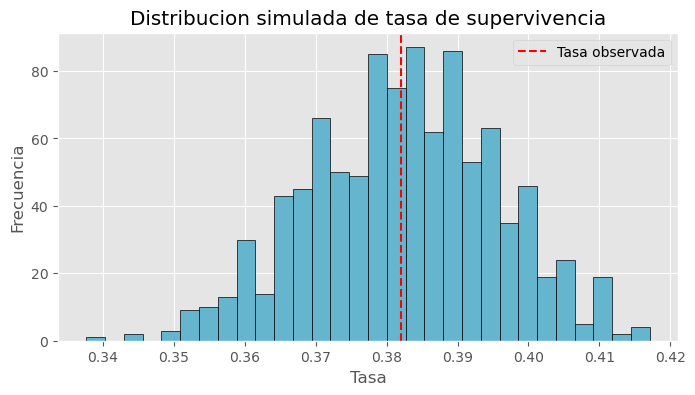

In [71]:
np.random.seed(2026)

p_survival = clean_df["survived"].mean()  # probabilidad observada
n = len(clean_df)
n_exp = 1000

sim_rates = []
for _ in range(n_exp):
    simulated = np.random.binomial(1, p_survival, n)
    sim_rates.append(simulated.mean())

print(f"Tasa observada de supervivencia: {p_survival:.4f}")
print(f"Promedio simulado ({n_exp} experimentos): {np.mean(sim_rates):.4f}")
print(f"Desv. estandar simulada: {np.std(sim_rates):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(sim_rates, bins=30, color="#64B5CD", edgecolor="black")
plt.axvline(p_survival, color="red", linestyle="--", label="Tasa observada")
plt.title("Distribucion simulada de tasa de supervivencia")
plt.xlabel("Tasa")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

## 12) Division entrenamiento/testing

### Que haremos

Separar datos en train/test con `train_test_split` y fallback manual si no esta `sklearn`.

### Por que se hace

Es una practica estandar para evitar sobreajuste cuando entrenas modelos.

### Que debes observar al ejecutar

- Proporcion cercana a 80/20.
- Sin perdida de filas.

### Resultado esperado

Conjuntos `X_train`, `X_test`, `y_train`, `y_test` listos para modelado.

In [74]:
target_col = "survived"

feature_cols = [
    c for c in model_df.columns
    if c not in ["name", "ticket", "cabin", "boat", "home.dest", target_col]
]

X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

try:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except Exception:
    # Fallback manual si sklearn no esta disponible
    np.random.seed(42)
    idx = np.random.permutation(len(X))
    cut = int(0.8 * len(X))
    train_idx, test_idx = idx[:cut], idx[cut:]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1047, 20)
X_test: (262, 20)
y_train: (1047,)
y_test: (262,)


## 13) Exportacion final de CSV (2 archivos)

### Que haremos

Exportar dos datasets finales:

- Uno a nivel pasajero (flexible para filtros y detalle).
- Uno agregado por segmento (rapido para visuales ejecutivos).

### Por que se hace

Esta separacion acelera el trabajo en Power BI: detalle + resumen en el mismo reporte.

### Que debes observar al ejecutar

- Confirmacion de rutas absolutas exportadas.
- Vista previa de `agg_output` con metricas agregadas.

### Resultado esperado

Dos archivos listos para importacion en Power BI.

In [77]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# 1) Dataset limpio a nivel de pasajero
clean_output_path = output_dir / "titanic_tratado_pasajero.csv"
clean_df.to_csv(clean_output_path, index=False)

# 2) Dataset agregado para dashboard
agg_output = (
    clean_df
    .groupby(["pclass", "sex", "embarked"], as_index=False)
    .agg(
        total_pasajeros=("survived", "count"),
        sobrevivientes=("survived", "sum"),
        tasa_supervivencia=("survived", "mean"),
        edad_promedio=("age", "mean"),
        tarifa_promedio=("fare", "mean"),
        familia_promedio=("family_size", "mean")
    )
)

agg_output["tasa_supervivencia"] = (agg_output["tasa_supervivencia"] * 100).round(2)
agg_output["edad_promedio"] = agg_output["edad_promedio"].round(2)
agg_output["tarifa_promedio"] = agg_output["tarifa_promedio"].round(2)
agg_output["familia_promedio"] = agg_output["familia_promedio"].round(2)

agg_output_path = output_dir / "titanic_tratado_agregado_dashboard.csv"
agg_output.to_csv(agg_output_path, index=False)

print("Archivo 1 exportado:", clean_output_path.resolve())
print("Archivo 2 exportado:", agg_output_path.resolve())

display(agg_output.head(10))

Archivo 1 exportado: C:\Users\garyDav\anaconda_projects\outputs\titanic_tratado_pasajero.csv
Archivo 2 exportado: C:\Users\garyDav\anaconda_projects\outputs\titanic_tratado_agregado_dashboard.csv


,pclass,sex,embarked,total_pasajeros,sobrevivientes,tasa_supervivencia,edad_promedio,tarifa_promedio,familia_promedio
0,1,female,C,71,69,97.18,37.25,118.90,1.82
1,1,female,Q,2,2,100.00,35.00,90.00,2.00
2,1,female,S,71,68,95.77,35.48,100.48,2.24
3,1,male,C,70,28,40.00,38.84,94.62,1.71
4,1,male,Q,1,0,0.00,44.00,90.00,3.00
5,1,male,S,108,33,30.56,39.04,53.67,1.55
6,2,female,C,11,11,100.00,19.36,27.00,2.45
7,2,female,Q,2,2,100.00,29.00,12.35,1.00
8,2,female,S,93,81,87.10,28.45,23.02,2.14
9,2,male,C,17,5,29.41,27.44,20.90,1.59


## Resultado esperado

Al finalizar debes tener:

- `outputs/titanic_tratado_pasajero.csv`
- `outputs/titanic_tratado_agregado_dashboard.csv`

### Recomendacion de validacion rapida

- Abre ambos CSV y confirma que no esten vacios.
- Verifica que `titanic_tratado_pasajero.csv` tenga muchas mas filas que el agregado.
- Revisa que `tasa_supervivencia` del agregado este en porcentaje (0-100), no en decimal (0-1).